In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

from os import system

from imf.cmf import *

In [2]:
tnow = 1

In [3]:
ml = 0.01
mu = 120

In [4]:
cmf = PN_CMF(ml,mu)

/blue/adamginsburg/richardson.t/dev/imf/imf/imf.py:52: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return scipy.integrate.quad(self.mass_weighted, mlow, mhigh, **kwargs)


Text(0.5, 0, 'log $\\tilde{\\rho}$')

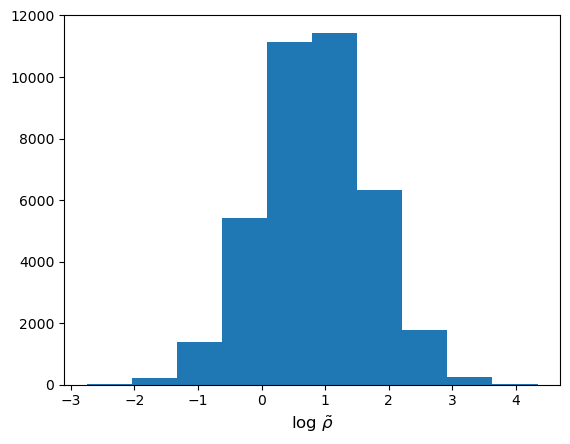

In [5]:
plt.hist(np.log10(cmf.rho.value / 2e-21))
plt.xlabel(r'log $\tilde{\rho}$',fontsize='large') 

In [6]:
tbe = (cmf.taccr * (cmf.maccr / cmf.mbe)**(-1/3.)).to(u.s)
tff = ((3 * np.pi / (32 * constants.G * cmf.rho))**0.5).to(u.s)
mmax = (cmf.maccr * ((tbe + tff) / cmf.taccr)**3).to(u.M_sun)
m_f = np.vstack([mmax.value, cmf.maccr.value]).min(axis=0)*u.M_sun

In [7]:
age = tnow * cmf.tcross - cmf.birthdays
isBorn = age > 0
isPrestellar = age < tbe + tff
belowBE = cmf.maccr < cmf.mbe
isStellar = np.logical_and(~isPrestellar,~belowBE)
isForming = age < cmf.taccr

In [8]:
mnow = ((age / cmf.taccr)**3 * cmf.maccr).to(u.M_sun)
mnow[mnow > cmf.maccr] = cmf.maccr[mnow > cmf.maccr]

In [9]:
toplot = isBorn & isPrestellar & isForming
gtmax = cmf.maccr > mmax

Text(0.5, 0, '$m_{\\rm accr}$ ($M_\\odot$)')

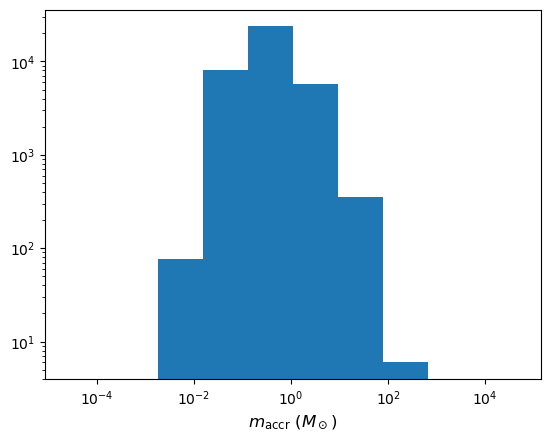

In [10]:
bins = 10**np.histogram_bin_edges(np.log(cmf.maccr.value))
#bins = np.geomspace(ml,mu,7)

plt.figure()
plt.hist(cmf.maccr.value,bins=bins)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$m_{\rm accr}$ ($M_\odot$)',fontsize='large')

Text(0.5, 0, '$m_{\\rm BE}$ ($M_\\odot$)')

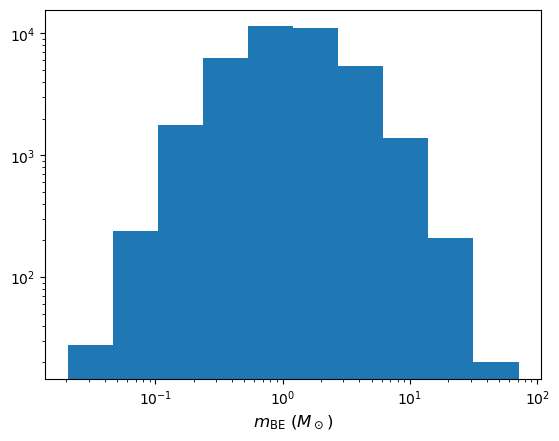

In [11]:
bins = 10**np.histogram_bin_edges(np.log10(cmf.mbe.value))

plt.figure()
plt.hist(cmf.mbe.value,bins=bins)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$m_{\rm BE}$ ($M_\odot$)',fontsize='large')

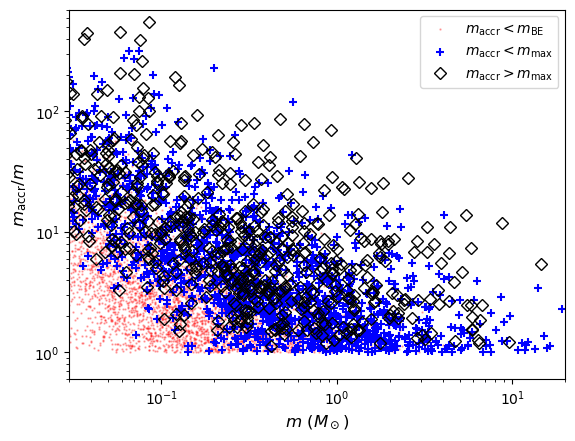

In [12]:
plt.figure()
plt.scatter(mnow[toplot & belowBE],
            cmf.maccr[toplot & belowBE]/mnow[toplot & belowBE],
            color='r',marker='.',
            alpha=0.3,
            s=2,
            label=r'$m_{\rm accr} < m_{\rm BE}$')
plt.scatter(mnow[toplot & ~gtmax & ~belowBE],
            cmf.maccr[toplot & ~gtmax & ~belowBE]/mnow[toplot & ~gtmax & ~belowBE],
        	color='b',marker='+',
            label=r'$m_{\rm accr} < m_{\rm max}$')
plt.plot(mnow[toplot & gtmax & ~belowBE],
         cmf.maccr[toplot & gtmax & ~belowBE]/mnow[toplot & gtmax & ~belowBE],
         'kD',markerfacecolor='none',
         label=r'$m_{\rm accr} > m_{\rm max}$')

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.03, 20)
plt.ylim(0.6,700)
plt.xlabel(r'$m$ ($M_\odot$)',fontsize='large')
plt.ylabel(r'$m_{\rm accr} / m$',fontsize='large')
plt.legend()

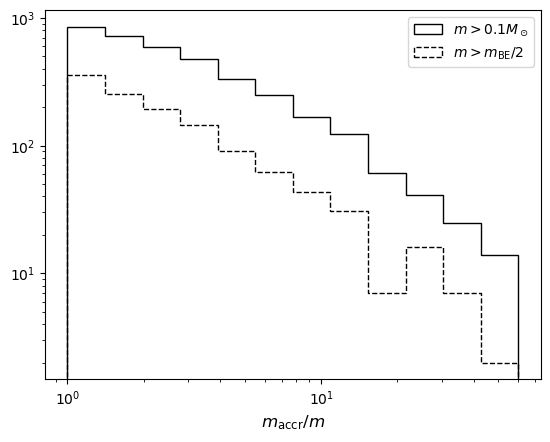

In [13]:
plt.figure()
edges = np.geomspace(1,60,13)
plt.hist((cmf.maccr / mnow)[(mnow > 0.1*u.M_sun) & toplot],
         bins=edges,histtype='step',color='k',
         label=r'$m > 0.1 M_\odot$')
plt.hist((cmf.maccr / mnow)[(mnow > (cmf.mbe / 2)) & toplot],
         bins=edges,histtype='step',linestyle='dashed',
         color='k',label=r'$m > m_{\rm BE} / 2$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$m_{\rm accr} / m$',fontsize='large')
plt.legend()

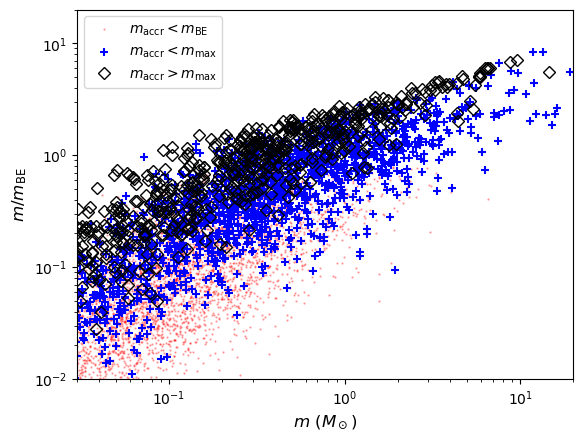

In [14]:
plt.figure()
plt.scatter(mnow[toplot & belowBE],
            (mnow / cmf.mbe)[toplot & belowBE],
            color='r',marker='.',
            alpha=0.3,
            s=2,
            label=r'$m_{\rm accr} < m_{\rm BE}$')
plt.scatter(mnow[toplot & ~gtmax & ~belowBE],
            (mnow / cmf.mbe)[toplot & ~gtmax & ~belowBE],
            color='b',marker='+',
            label=r'$m_{\rm accr} < m_{\rm max}$')
plt.plot(mnow[toplot & gtmax & ~belowBE],
         (mnow / cmf.mbe)[toplot & gtmax & ~belowBE],
         'kD',markerfacecolor='none',
         label=r'$m_{\rm accr} > m_{\rm max}$')
'''
ct, bn = np.histogram(mnow[(mnow > mbe/2.) & toplot & (maccr < mbe)],
                      bins=np.logspace(np.log10(0.05), np.log10(20)))
ctall, bn = np.histogram(mnow[(mnow > mbe/2.) & toplot],
                         bins=np.logspace(np.log10(0.05), np.log10(20)))
bbn = (bn[1:]+bn[:-1])/2.
pl.loglog(bbn, ct/ctall.astype('float'), 'k-')
'''
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.03,20)
plt.ylim(0.01,20)
plt.xlabel(r'$m$ ($M_\odot$)',fontsize='large')
plt.ylabel(r'$m / m_{\rm BE}$',fontsize='large')
plt.legend()

In [15]:
nbins = 50
nreal = 5

/blue/adamginsburg/richardson.t/dev/imf/imf/imf.py:52: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return scipy.integrate.quad(self.mass_weighted, mlow, mhigh, **kwargs)


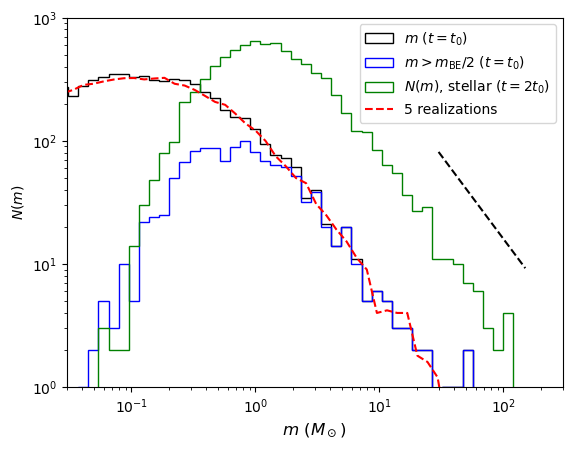

In [16]:
plt.figure()
edges = np.geomspace(ml,mu,nbins+1)
plt.hist(mnow[toplot].value, bins=edges, histtype='step',
         edgecolor='k', label=r'$m$ ($t=t_0$)')
plt.hist(mnow[toplot & (mnow > cmf.mbe / 2)].value, bins=edges,
         histtype='step',color='b',
         label=r'$m > m_{\rm BE} / 2$ ($t=t_0$)')

_, _, masses = cmf(tnow=2,cores='stellar',visible_only=False,return_masses=True)
plt.hist(masses.value, bins=edges,
         histtype='step',color='g',
         label=r'$N(m)$, stellar ($t=2t_0$)')

all_ms = []
for i in range(nreal):
    mf = PN_CMF(ml,mu)    

    _, _, masses_ = mf(tnow=tnow,visible_only=True,return_masses=True)
    all_ms.extend(masses_)
    
all_ms = np.array([v.value for v in all_ms])
counts, edges = np.histogram(all_ms,bins=edges)
av_edges = (edges[:-1] + edges[1:]) / 2.
plt.plot(av_edges,counts/nreal,'r--',label=f'{nreal} realizations')

plt.plot(np.geomspace(30,150),8e3 * np.geomspace(30,150)**-1.35,'k--')

plt.xscale('log')
plt.yscale('log')
plt.xlim(0.03,300)
plt.ylim(1,1e3)
plt.xlabel(r'$m$ ($M_\odot$)',fontsize='large')
plt.ylabel(r'$N(m)$')
plt.legend()

In [17]:
n,bins,masses = cmf(tnow=1,visible_only=False,cores='stellar',
                    return_masses=True)
#cut = masses < cmf.maccr
print(np.sum(masses) / (np.sum(masses) + (1.1e5 * u.M_sun)))

0.06633987221831493


In [18]:
n,bins,masses = cmf(tnow=10,visible_only=False,cores='stellar',
                    return_masses=True)
#cut = masses < cmf.maccr
print(np.sum(masses) / (np.sum(masses) + (1.1e5 * u.M_sun)))

0.16009938551437378


In [19]:
masses

<Quantity [ 3.56558601,  2.68659129,  3.85459186, ...,  0.77677497,
            1.09392564, 22.99858199] solMass>